# 4. Breaking wave loads

In [196]:
import numpy as np              
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow


plt.rcParams['figure.figsize'] = (15, 8)   # set the width and height of plots in inches
plt.rcParams.update({'font.size': 13})     # change this value to your desired font size

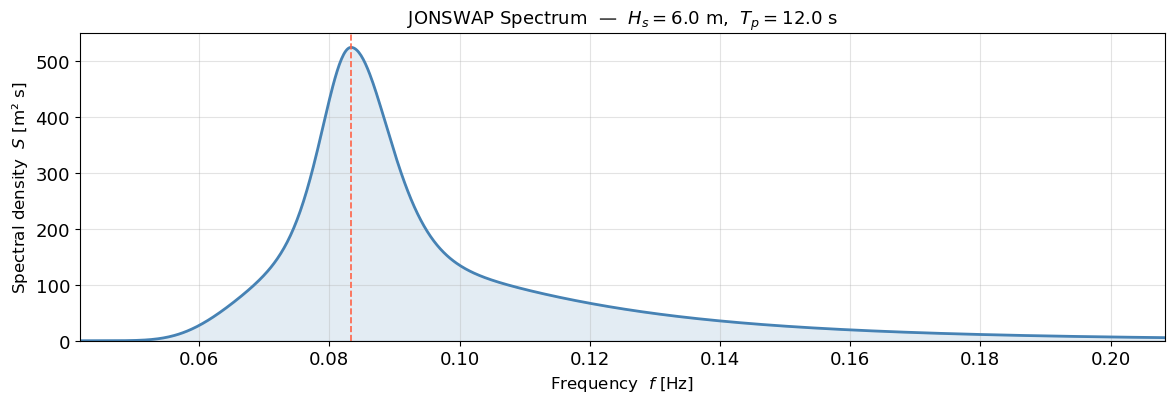

In [197]:
# Parameters
R     = 4.0         # Cylinder radius (m)
rho   = 1025.0      # Water density (kg/m³)
g     = 9.81        # Gravitational acceleration (m/s²)
h     = 35.0        # Water depth (m)

# Johnswap
H_s = 6.0           # Significant wave height [m]
T_p = 12.0           # Peak period [s]
f_p = 1/T_p

def jonswap(f, H_s, T_p, gamma=3.3):
    """
    JONSWAP wave spectrum E(f) [m² s].
    """
    fp = 1.0 / T_p
    alpha = 0.0624 / (0.230 + 0.0336*gamma - 0.185*(1.9 + gamma)**-1)
    tau = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-(f - fp)**2 / (2* tau**2 * fp**2))
    S = (2*np.pi * alpha * H_s**2
         * (f**(-5) / fp**(-4))
         * np.exp(-5/4 * (f/fp)**(-4))
         * gamma**r)
    return S

# Plot Jonswap
f_plot = np.linspace(0.5 * fp, 2.5 * fp, 1000)
S_plot = jonswap(f_plot, H_s, Tp)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 4))

ax1.plot(f_plot, S_plot, color="steelblue", lw=2)
ax1.axvline(fp, color="tomato", lw=1.2, ls="--", label=f"$f_p = 1/T_p = {fp:.3f}$ Hz")
ax1.fill_between(f_plot, S_plot, alpha=0.15, color="steelblue")
ax1.set_xlabel("Frequency  $f$ [Hz]", fontsize=12)
ax1.set_ylabel("Spectral density  $S$ [m² s]", fontsize=12)
ax1.set_title(f"JONSWAP Spectrum  —  $H_s = {H_s}$ m,  $T_p = {Tp}$ s", fontsize=13)
ax1.set_xlim(f_plot[0], f_plot[-1])
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.35)

In [198]:
#solve the dispertion relation using Newton-Rhapson
def waveNumber_dispertionRelation_NewtonRhapson(T, d, tolerance=1e-6):
    """
    Solve the dispersion relation for water waves using Newton-Raphson method.
    
    The dispersion relation is: ω² = gk·tanh(kd)
    Or equivalently: (2π/T)² = gk·tanh(kd)
    
    We solve: f(k) = gk·tanh(kd) - (2π/T)² = 0
    
    Parameters:
    -----------
    T : float
        Wave period (seconds)
    d : float
        Water depth (meters)
    tolerance : float
        Convergence tolerance (default: 1e-6)
    
    Returns:
    --------
    k : float
        Wave number (rad/m)
    """
    g = 9.81  # Gravitational acceleration (m/s²)
    omega = 2 * np.pi / T  # Angular frequency
    omega_squared = omega ** 2
    
    # Initial guess for k using deep water approximation: k ≈ ω²/g
    k = omega_squared / g
    
    # Newton-Raphson iteration
    max_iterations = 100
    for iteration in range(max_iterations):
        # Calculate f(k) = g*k*tanh(k*d) - ω²
        tanh_kd = np.tanh(k * d)
        f = g * k * tanh_kd - omega_squared
        
        # Calculate f'(k) = g*tanh(k*d) + g*k*d*sech²(k*d)
        # where sech²(k*d) = 1 - tanh²(k*d)
        sech_squared_kd = 1 - tanh_kd ** 2
        df = g * tanh_kd + g * k * d * sech_squared_kd
        
        # Newton-Raphson update: k_new = k_old - f(k)/f'(k)
        k_new = k - f / df
        
        # Check convergence
        if abs(k_new - k) < tolerance:
            return k_new
        
        k = k_new
    
    # If max iterations reached without convergence
    print(f"Warning: Newton-Raphson did not converge within {max_iterations} iterations")
    return k

### 4.1 Slamming waves

### 4.2 Slamming-load timeseries and point of application

In [199]:
# Sample slamming wave characteristics
H_b = 18.0   # Sample wave breaking height [m]
T_b = 12    # Sample wave breaking period [s]


# STEP 1: Derived wave parameters
# =============================================================================
T_s = T_p / 1.07    # Sample wave breaking period [s]
omega = 2 * np.pi / T_s 
k = waveNumber_dispertionRelation_NewtonRhapson(T_s, h)
c = omega / k                   # wave speed at breaking
lam = 0.46                      # Curling factor for plunging breakers

t = 13/32 * R /c # Duration of the impact

x = np.linspace(0, R, 100)
eta_b = R - np.sqrt(R**2 - x**2)
eta_b = 0.775 * H_b        # (m) — crest elevation
ell = lam * eta_b          # effective length of the impact zone # λ * η_b  (m)

print("=" * 55)
print("  Parameters")
print("=" * 55)
print(f"\n  Wave period          T_s  = {T_s:.2f} s")
print(f"  Breaking wave height H_b  = {H_b:.2f} m")
print(f"  Wave celerity        c    = {c:.3f} m/s")
print(f"  Crest elevation      η_b  = {eta_b:.3f} m")
print(f"  Curling factor       λ    = {lam}")
print(f"  Impact zone height   λη_b = {ell:.3f} m")
print(f"  Cylinder radius      R    = {R:.2f} m")

# STEP 2: Time axis — two phases defined in the 3D model
#  Phase 1 (F1): 0  <=  t  <=  (1/8)*(R/c)   =>  0 <= x <= R/√2
#  Phase 2 (FI): defined with shifted time t' = t - (1/32)*(R/c)
#                for  (3/32)*(R/c)  <=  t'  <=  (12/32)*(R/c)
# =============================================================================

# Phase 1 time limits
t1_end = (1/8) * (R / c)                                # end of Phase 1

# Phase 2 uses shifted time t' = t - (1/32)*(R/c)
t2_prime_start = (3/32) * (R / c)                       # t' start
t2_prime_end = (12/32) * (R / c)                        # t' end  (= 13R/32c total)

t_shift = (1/32) * (R / c)                              # time offset for t'
t2_start = t2_prime_start+ t_shift                 # t' start
t2_end = t2_prime_end + t_shift         # t' end  (= 13R/32c total)
t_check_end = (13/32) * (R / c)                         # t end check (should match t2_end_shifted)

# Full time vector covering both phases
N = 2000
t_arr = np.linspace(0, t2_end * 1.3, N)

print()
print("=" * 55)
print("  TIME SERIES")
print("=" * 55)
print(f"\n  Phase 1: 0 <= t <= {t1_end:.3f} s")
print(f"  Phase 2: {t2_start:.3f} s <= t' <= {t2_end:.3f} s")
print(f"  Phase 2 shifted time: {t2_prime_start:.3f} s <= t <= {t2_prime_end:.3f} s")
print(f'  Total duration: {t2_end:.3f} s (end t2) should be {t_check_end:.3f} s (13/32 R/c)')

  Parameters

  Wave period          T_s  = 11.21 s
  Breaking wave height H_b  = 18.00 m
  Wave celerity        c    = 15.087 m/s
  Crest elevation      η_b  = 13.950 m
  Curling factor       λ    = 0.46
  Impact zone height   λη_b = 6.417 m
  Cylinder radius      R    = 4.00 m

  TIME SERIES

  Phase 1: 0 <= t <= 0.033 s
  Phase 2: 0.033 s <= t' <= 0.108 s
  Phase 2 shifted time: 0.025 s <= t <= 0.099 s
  Total duration: 0.108 s (end t2) should be 0.108 s (13/32 R/c)


In [200]:
# STEP 3: Force calculation — Phase 1 (F1) and Phase 2 (FI)
# =============================================================================
def F1(t, lam, eta_b, rho, R, c):
    """
    Phase 1 slamming force — wave front rising up the cylinder face.

    F1 = λ·η_b·ρ·R·c² · (2π - 2·√(c/R·t) · artanh(√(1 - (c/(4R)·t))))

    Valid for: 0 ≤ t ≤ (1/8)·(R/c)
    At t=0: F1 = λ·η_b·ρ·R·c²·2π  (limit value, Wagner peak)
    """
    if t <= 0:
        return lam * eta_b * rho * R * c**2 * 2 * np.pi
    arg_sqrt = c / R * t
    tanh_arg = np.clip(1 - (c / (4 * R)) * t, 0, 1)
    tanh_val = np.arctanh(np.sqrt(tanh_arg)) if tanh_arg < 1 else 0.0
    return lam * eta_b * rho * R * c**2 * (
        2 * np.pi - 2 * np.sqrt(arg_sqrt) * tanh_val
    )


def FI(t_prime, lam, eta_b, rho, R, c):
    """
    Phase 2 slamming force — wave wrapping around cylinder sides.

    FI = λ·η_b·ρ·R·c² · (π·√(1/(6·(c/R)·t')) 
                          - (4/3)·√(8c/(3R)·t') · artanh(√(1 - (c/R)·t') · √(6c/R·t')))

    Valid for: (3/32)·(R/c) ≤ t' ≤ (12/32)·(R/c)
    """
    ratio = c / R * t_prime
    term1 = np.pi * np.sqrt(1 / (6 * ratio))
    inner = np.sqrt(1 - ratio * np.sqrt(6 * ratio))
    term2 = (8 /3 * ratio)**(1/4) * np.arctanh(np.clip(inner, 0, 0.9999))
    return lam * eta_b * rho * R * c**2 * (term1 - term2)


# Build composite force time history
F_arr = np.zeros(N)

for i, t in enumerate(t_arr):
    if t <= t1_end:
        # Phase 1
        F_arr[i] = F1(t, lam, eta_b, rho, R, c)
    else:
        # Phase 2 — use shifted time t'
        t_prime = t - t_shift
        if t2_prime_start <= t_prime <= t2_prime_end:
            F_arr[i] = FI(t_prime, lam, eta_b, rho, R, c)
        else:
            F_arr[i] = 0.0  # outside defined range


# STEP 4: Key results
# =============================================================================
F_max = np.max(F_arr)
tons_max = F_max / 1e6 * 101.9716213  # Convert N to tons-force
t_at_max = t_arr[np.argmax(F_arr)]
duration = t2_end + t_shift   # total impact duration (s)

print(f"  --- RESULTS ---")
print(f"  Peak slamming force  F_max  = {F_max/1e6:.4f} MN  ({F_max:.2f} N)")
print(f"  Peak slamming force  F_max  = {tons_max:.4f} tons-force")
print(f"  Time of peak         t_peak = {t_at_max*1000:.4f} ms")
print(f"  Total impact duration       = {duration*1000:.4f} ms")
print(f"  Impact length on pile  λη_b   = {ell:.3f} m above SWL")
print(f"  Impact zone top      η_b    = {eta_b:.3f} m above SWL")
print(f"  Impact zone bottom   η_b-λη = {eta_b - ell:.3f} m above SWL")
print(f"  Impact point         η_b-λη/2 = {eta_b - ell/2:.3f} m above SWL")

  --- RESULTS ---
  Peak slamming force  F_max  = 37.6290 MN  (37628950.04 N)
  Peak slamming force  F_max  = 3837.0850 tons-force
  Time of peak         t_peak = 0.0000 ms
  Total impact duration       = 115.9912 ms
  Impact length on pile  λη_b   = 6.417 m above SWL
  Impact zone top      η_b    = 13.950 m above SWL
  Impact zone bottom   η_b-λη = 7.533 m above SWL
  Impact point         η_b-λη/2 = 10.742 m above SWL


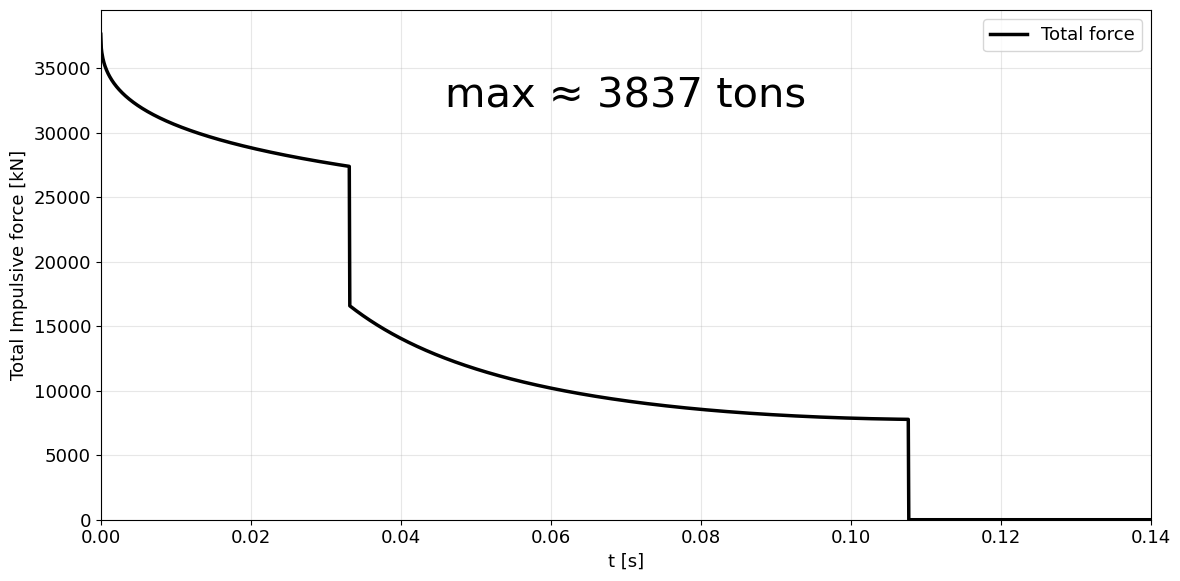

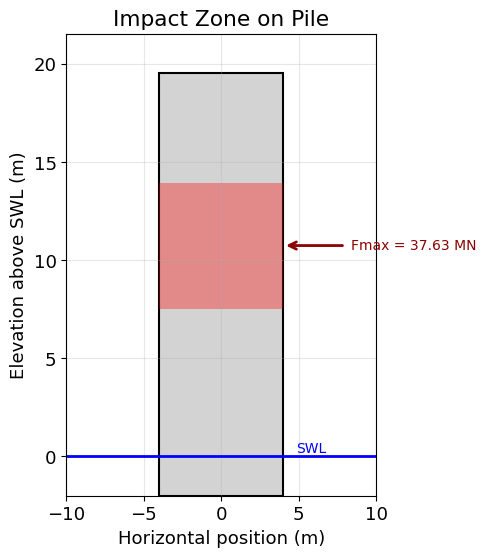

<Figure size 1500x800 with 0 Axes>

In [201]:
# STEP 5: Plot
# =============================================================================
plt.figure(figsize=(12,6))

plt.plot(t_arr, F_arr/1000, color='black', linewidth=2.5, label="Total force")
plt.xlabel("t [s]", fontsize=13)
plt.ylabel("Total Impulsive force [kN]", fontsize=13)
plt.text(
    0.5*(t_arr.max()),
    0.85*(F_max/1000),
    f"max ≈ {tons_max:.0f} tons",
    fontsize=30,
    ha='center'
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, t_arr.max())
plt.ylim(0, np.max(F_arr/1000)*1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,6))

pile_height = eta_b * 1.4
plt.xlim(-R*2.5, R*2.5)
plt.ylim(-2, pile_height + 2)

# Pile
pile = Rectangle((-R, -2), 2*R, pile_height+2,
                 facecolor='lightgray', edgecolor='black', linewidth=1.5)
plt.gca().add_patch(pile)

# Still water level
plt.axhline(0, color='blue', linewidth=2)
plt.text(R*1.2, 0.2, "SWL", color='blue', fontsize=10)

# Impact zone
impact_bot = eta_b - ell
impact = Rectangle((-R, impact_bot), 2*R, ell,
                   facecolor='red', alpha=0.35)
plt.gca().add_patch(impact)

# Force arrow
y_mid = (impact_bot + eta_b) / 2
plt.annotate("",
             xy=(R, y_mid),
             xytext=(R*2.0, y_mid),
             arrowprops=dict(arrowstyle="->", lw=2, color="darkred"))

plt.text(R*2.1, y_mid,
         f"Fmax = {F_max/1e6:.2f} MN",
         color="darkred", va="center", fontsize=10)

# Labels
plt.xlabel("Horizontal position (m)")
plt.ylabel("Elevation above SWL (m)")
plt.title("Impact Zone on Pile")

plt.grid(alpha=0.3)
plt.show()

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/wienke_oumeraci_slamming.png", dpi=150, bbox_inches='tight')
# print("\n  Plot saved to wienke_oumeraci_slamming.png")
plt.show()

Questions: 
- What to wave period to take? Ppt seems to say $T_p/1.07$ but i can also get it from $T_{breaking}$?